# Architecture Comparison — equal tuning budget for every model

**The problem this fixes.** Only the U-Net has ever been hyperparameter-searched on
line-emission data. The autoencoder and VAE numbers still quoted in the report are Week-2
results on **64×64 continuum patches** — different data, different resolution, no tuning — and
the DDPM was hand-tuned once. "The U-Net is the best architecture" cannot be concluded from
that: the tuning budget is confounded with the architecture.

Two defects had to be fixed before any comparison could even be run, and they biased it in
**opposite** directions:

1. The AE and VAE ended in `nn.Sigmoid`. Under the shared dirty-scale normalisation the clean
   target routinely exceeds 1, so a sigmoid **cannot represent the target at all** — the same
   defect whose removal from the U-Net took Moment-0 from −6402% to positive. Left in place, the
   U-Net would win for a reason unrelated to architecture. Both are now built with linear heads.
2. Neither was parameterised — `DenoisingAutoencoder.__init__` took *no arguments* — so neither
   could be swept even in principle. Both now expose `base_channels`, matching the U-Net's width
   knob.

**What "equal budget" means here.** Every architecture gets the same `N_RUNS` random-search
runs, the same seed, the same cube-level split, the same fixed PSNR/SSIM/MSE scoring, and the
same early-stopping schedule. Only the model and its natural hyperparameters differ. The VAE
additionally searches `kl_weight`, because its objective genuinely has an extra term — omitting
it would handicap the VAE the way the sigmoid did.

**Then the scientific metric decides.** The best configuration of each architecture goes through
the all-5-holdout moment-map protocol, and §7 shows the actual M0/M1/M2 maps. Every prior
lesson in this project says pixel metrics alone mislead: the beam A/B improved PSNR while M0
regressed, and V16's sweep winner scored 37.11 dB in one run and 30.28 dB in another.

**Cost — measured, not estimated.** The first attempt took **259.8 min for the U-Net's 8 runs
alone**, because a `base_channels=64` configuration costs ~112 s/epoch against ~21 s for
`base_channels=16`. Budget roughly **7–9 h for all 24 runs**, not the 5–7 h originally guessed.

That exceeds a single Kaggle session, so this notebook is built to resume: every sweep row is
written as it completes, and section 1b restores them. Reduce `N_RUNS` if quota is tight — but
keep it *equal across architectures*, which is the whole point.

## 0. Bootstrap

In [1]:
import os, sys, subprocess, glob

ON_KAGGLE = os.path.exists('/kaggle')
BRANCH = 'midterm-prep'
if ON_KAGGLE:
    REPO='/kaggle/working/EXXA'; PKG=os.path.join(REPO,'DENOISING_DIFFUSION')
    if not os.path.exists(REPO):
        subprocess.run(['git','clone','--branch',BRANCH,'--depth','1',
                        'https://github.com/KrishanYadav333/EXXA.git',REPO], check=True)
    else:
        subprocess.run(['git','-C',REPO,'fetch','origin',BRANCH], check=True)
        subprocess.run(['git','-C',REPO,'reset','--hard','origin/'+BRANCH], check=True)
    subprocess.run([sys.executable,'-m','pip','install','-q','--no-deps',
                    'pytorch-msssim','bettermoments'], check=True)
    os.chdir(os.path.join(PKG,'notebooks'));  sys.path.insert(0, PKG)
    # Fail here, loudly, if the dataset is not attached. Returning None instead
    # defers the error to the first os.path.join two cells later, where it reads as
    # "TypeError: expected str ... not NoneType" and says nothing about the cause.
    hits = (glob.glob('/kaggle/input/**/*_dirty.fits', recursive=True)
            or glob.glob('/kaggle/input/**/*dirty*.fits', recursive=True))
    if not hits:
        avail = sorted(glob.glob('/kaggle/input/*'))
        raise FileNotFoundError(
            'No *_dirty.fits found under /kaggle/input.\n'
            'The line-emission Dataset is probably not attached: '
            'Add Input -> Datasets -> your line-emission cubes.\n'
            f'Currently attached: {avail if avail else "(nothing)"}')
    DATA_DIR = os.path.dirname(os.path.dirname(hits[0]))
else:
    if os.path.basename(os.getcwd()) != 'notebooks' and os.path.isdir('notebooks'): os.chdir('notebooks')
    sys.path.insert(0, os.path.abspath('..'))
    DATA_DIR = '../data/Line Emission Data'
print('cwd:', os.getcwd(), '| DATA_DIR:', DATA_DIR)

Cloning into '/kaggle/working/EXXA'...
Updating files: 100% (5109/5109), done.


cwd: /kaggle/working/EXXA/DENOISING_DIFFUSION/notebooks | DATA_DIR: /kaggle/input/datasets/krishanyadav333/line-emission-data/Line Emission Data


## 0b. Pull latest code (re-run anytime — no kernel restart)

In [2]:
import os, sys, subprocess
ON_KAGGLE = os.path.exists('/kaggle'); REPO='/kaggle/working/EXXA'; BRANCH='midterm-prep'
if ON_KAGGLE and os.path.exists(REPO):
    subprocess.run(['git','-C',REPO,'fetch','origin',BRANCH], check=True)
    subprocess.run(['git','-C',REPO,'reset','--hard','origin/'+BRANCH], check=True)
    print(subprocess.run(['git','-C',REPO,'log','--oneline','-1'],
                         capture_output=True, text=True).stdout.strip())
for _m in [m for m in list(sys.modules) if m == 'src' or m.startswith('src.')]:
    del sys.modules[_m]
print('src.* cleared — re-run the imports cell below.')

From https://github.com/KrishanYadav333/EXXA
 * branch            midterm-prep -> FETCH_HEAD


HEAD is now at ee491fc fix(nb09): resume trusted stale pre-M2-fix cube rows as if already correct
ee491fc fix(nb09): resume trusted stale pre-M2-fix cube rows as if already correct
src.* cleared — re-run the imports cell below.


## 1. Imports, device, config

In [3]:
import csv, math, time
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from src.data.cube_split import split_cubes
from src.data.fits_cube_dataset import FITSChannelDataset, continuum_of
from src.training.sweep import run_sweep, train_unet
from src.training.architectures import (build_model, forward_fn, param_count,
                                        search_space, supported)
from src.evaluation.classical import summarise_improvements

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
N_GPU = torch.cuda.device_count()
SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
print('device:', device, '| GPUs:', N_GPU)

TARGET_SIZE, N_SAMPLES = 256, 150
SUBTRACT_CONTINUUM, CONTINUUM_N = True, 5
N_RUNS = 8                      # runs PER ARCHITECTURE -- keep equal across architectures
ARCHS  = list(supported())      # unet, autoencoder, vae
NW = 2 if ON_KAGGLE else 0
OUT_DIR, CKPT_DIR = '../results', '../results/checkpoints'
os.makedirs(OUT_DIR, exist_ok=True); os.makedirs(CKPT_DIR, exist_ok=True)

V12 = {'psnr': 32.95, 'M0': (69.8, 15.2), 'M1': (17.5, 7.8), 'M2': (20.1, 14.3)}

print(f'\narchitectures: {ARCHS}  |  {N_RUNS} runs each = {N_RUNS*len(ARCHS)} trainings')
for a in ARCHS:
    print(f'  {a:<12} search space: {sorted(search_space(a))}')

device: cuda | GPUs: 2

architectures: ['unet', 'autoencoder', 'vae']  |  8 runs each = 24 trainings
  unet         search space: ['alpha', 'base_channels', 'channel_multipliers', 'lr', 'sched_patience']
  autoencoder  search space: ['alpha', 'base_channels', 'lr', 'sched_patience']
  vae          search space: ['alpha', 'base_channels', 'kl_weight', 'latent_dim', 'lr', 'sched_patience']


## 1b. Restore a previous session (resume a partial sweep)

`run_sweep` appends a CSV row the moment each run finishes, so an interrupted sweep loses at
most the run in flight. It saves no checkpoints, and does not need to: only the scores decide
which configuration wins, and section 6 retrains that winner from scratch anyway.

The CSV lives inside `/kaggle/working/EXXA`, which the bootstrap wipes with `git reset --hard`.
Section 4 now also copies it to the top level of `/kaggle/working` after each architecture, where
it becomes the notebook's **Output**.

**To resume:** `Add Input` → `Notebook Output` → the previous version of this notebook, then run
normally. Completed runs are skipped and their scores reused. The configuration sampler is a
seeded RNG consumed in order, and the draw still happens for skipped indices, so a resumed sweep
explores exactly the same space as an uninterrupted one.

In [4]:
import glob, shutil

# Write the sweep CSV DIRECTLY to /kaggle/working, not into the git clone under it.
# run_sweep appends a row per finished run, so the file is only useful if it survives
# the session -- and a file buried in /kaggle/working/EXXA/... depends on the whole
# clone being captured. At the top level it is unambiguously part of the notebook
# Output, updated after every single run rather than every architecture.
SWEEP_CSV = ('/kaggle/working/architecture_sweep.csv' if ON_KAGGLE
             else os.path.join(OUT_DIR, 'architecture_sweep.csv'))

def _merge_csv(pattern, dst, key_fields, valid):
    """Union every attached copy of a resume CSV, not just the most recent one.

    Taking hits[-1] by mtime silently discards work: a session that completed 24 sweep
    runs and a later one that completed 10 both produce an architecture_sweep.csv, and
    the NEWER file is the SMALLER one. Attaching both inputs -- the obvious thing to do
    when trying to recover -- would then restore 10 runs and re-run the other 14. The
    configuration sampler is a seeded RNG consumed in order, so run index N is the same
    configuration in every session and rows from different sessions are interchangeable.
    """
    hits = sorted(glob.glob(pattern, recursive=True), key=os.path.getmtime)
    if not hits or os.path.exists(dst):
        return 0
    merged, header = {}, None
    for h in hits:
        with open(h, newline='') as f:
            rd = csv.DictReader(f)
            for r in rd:
                if header is None:
                    header = rd.fieldnames
                if not valid(r):
                    continue
                merged[tuple((r.get(k) or '').strip() for k in key_fields)] = r
    if not merged:
        return 0
    os.makedirs(os.path.dirname(dst) or '.', exist_ok=True)
    with open(dst, 'w', newline='') as f:
        w = csv.DictWriter(f, fieldnames=header)
        w.writeheader()
        for r in merged.values():
            w.writerow({k: r.get(k, '') for k in header})
    print(f'restored {os.path.basename(dst)}: {len(merged)} row(s) merged from '
          f'{len(hits)} attached copy/copies')
    for h in hits:
        print('   ', h)
    return len(merged)


def _psnr_ok(r):
    try:
        float(r.get('psnr'))
        return True
    except (TypeError, ValueError):
        return False


if ON_KAGGLE:
    _merge_csv('/kaggle/input/**/architecture_sweep.csv', SWEEP_CSV,
               ('arch', 'run'), _psnr_ok)

# Section 6 (retrain + 5-cube scoring) needs the same treatment as the sweep. It used to
# hold everything in memory and write nothing until section 9, so a session that died after
# the U-Net retrain -- which is exactly what happened -- threw away both the 23-epoch retrain
# and every cube already scored, with the sweep hours ahead of it still intact but unusable.
ARCH_CSV = ('/kaggle/working/architecture_moment_rows.csv' if ON_KAGGLE
            else os.path.join(OUT_DIR, 'architecture_moment_rows.csv'))
MAPS_NPZ = ('/kaggle/working/architecture_moment_maps.npz' if ON_KAGGLE
            else os.path.join(OUT_DIR, 'architecture_moment_maps.npz'))

if ON_KAGGLE:
    # same union treatment: a partially-scored section 6 in one session and a differently
    # partial one in another must add up, not overwrite each other
    _merge_csv('/kaggle/input/**/architecture_moment_rows.csv', ARCH_CSV,
               ('arch', 'cube'), lambda r: bool((r.get('arch') or '').strip()))

    _h = sorted(glob.glob('/kaggle/input/**/architecture_moment_maps.npz', recursive=True),
                key=os.path.getmtime)
    if _h and not os.path.exists(MAPS_NPZ):
        shutil.copy2(_h[-1], MAPS_NPZ)       # figures only; newest is fine
        print('restored architecture_moment_maps.npz from', _h[-1])
    # retrained checkpoints: 20-60 epochs each, worth strictly more than the time to copy
    os.makedirs(CKPT_DIR, exist_ok=True)
    for _h in sorted(glob.glob('/kaggle/input/**/arch_*_best.pth', recursive=True),
                     key=os.path.getmtime):
        _dst = os.path.join(CKPT_DIR, os.path.basename(_h))
        if not os.path.exists(_dst):
            shutil.copy2(_h, _dst); print('restored', os.path.basename(_h))

if os.path.exists(SWEEP_CSV):
    import pandas as _pd
    _d = _pd.read_csv(SWEEP_CSV)
    _d = _d[_pd.to_numeric(_d.psnr, errors='coerce').notna()]
    print('runs already scored:')
    for a, g in _d.groupby('arch'):
        print(f"  {a:<12} {len(g)} run(s) | best PSNR {g.psnr.max():.3f}")
    print('\nthese will be SKIPPED; the sweep continues from where it stopped.')
else:
    print('no previous sweep CSV — this is a fresh run'
          + (' (attach the previous notebook Output to resume)' if ON_KAGGLE else ''))

if os.path.exists(ARCH_CSV):
    import collections as _c
    _seen = _c.Counter()
    with open(ARCH_CSV, newline='') as _f:
        for _r in csv.DictReader(_f):
            _seen[_r['arch']] += (_r['cube'] or '').strip() not in ('', 'RETRAIN')
    print('\nsection 6 progress:', dict(_seen), '-- fully scored architectures are skipped')

restored architecture_sweep.csv from /kaggle/input/notebooks/deepsceneloc/09-architecture-comparison2/architecture_sweep.csv
restored architecture_moment_rows.csv from /kaggle/input/notebooks/deepsceneloc/09-architecture-comparison2/architecture_moment_rows.csv
restored architecture_moment_maps.npz from /kaggle/input/notebooks/deepsceneloc/09-architecture-comparison2/architecture_moment_maps.npz
restored arch_autoencoder_best.pth
restored arch_vae_best.pth
restored arch_unet_best.pth
runs already scored:
  autoencoder  8 run(s) | best PSNR 33.633
  unet         8 run(s) | best PSNR 39.235
  vae          8 run(s) | best PSNR 30.498

these will be SKIPPED; the sweep continues from where it stopped.

section 6 progress: {'unet': 5, 'autoencoder': 5, 'vae': 5} -- fully scored architectures are skipped


## 2. Cube split — identical for every architecture

In [5]:
train_cubes, val_cubes, holdout_cubes = split_cubes(data_dir=DATA_DIR, n_holdout=3,
                                                     val_fraction=0.2, seed=SEED)

CUBE-LEVEL SPLIT (grouped by RunID — no channel-level leakage)
  data_dir          : /kaggle/input/datasets/krishanyadav333/line-emission-data/Line Emission Data
  total cubes       : 14  across 11 distinct RunIDs
  seed=42  n_holdout=3  val_fraction=0.2
----------------------------------------------------------------------
  TRAIN   :  7 cubes | RunIDs ['0006', '0010', '0020', '0022', '0030', '0035']
  VAL     :  2 cubes | RunIDs ['0016', '0036']
  HOLDOUT :  5 cubes | RunIDs ['0002', '0025', '0026']  <-- inference only, NEVER trained/validated
----------------------------------------------------------------------
  HOLDOUT cube folders (reserved for moment-map evaluation):
    - run_0002_00560_rt_00
    - run_0002_00560_rt_01
    - run_0002_00560_rt_04
    - run_0025_01000_rt_04
    - run_0026_00005_rt_04


## 3. Datasets — one set, shared by every architecture

In [6]:
common = dict(n_samples=N_SAMPLES, target_size=TARGET_SIZE, seed=SEED,
              subtract_continuum=SUBTRACT_CONTINUUM, continuum_n=CONTINUUM_N)
train_ds = FITSChannelDataset(train_cubes, **common)
val_ds   = FITSChannelDataset(val_cubes,   **common)
print('train:', len(train_ds), '| val:', len(val_ds))

# every architecture must be able to represent a target above 1 -- the defect that
# made the sigmoid-headed AE/VAE structurally unable to compete
cl_max = max(float(val_ds[i][1].max()) for i in range(min(40, len(val_ds))))
print(f'max clean value seen in validation: {cl_max:.3f}'
      f'  ({"exceeds 1 -- linear heads required" if cl_max > 1 else "within [0,1]"})')

[FITSChannelDataset] 7 cubes x ~150 channels = 1050 items | target 256x256 | continuum-subtracted (mean of first/last 5 channels)
[FITSChannelDataset] 2 cubes x ~150 channels = 300 items | target 256x256 | continuum-subtracted (mean of first/last 5 channels)
train: 1050 | val: 300
max clean value seen in validation: 1.085  (exceeds 1 -- linear heads required)


## 4. Equal-budget sweep

`run_sweep` samples from each architecture's own space but shares the seed, split, scoring
metric and early-stopping schedule. Rows append to one CSV as they finish, so a session timeout
costs at most one run.

In [7]:
sweep_results = {}
t_all = time.time()

for arch in ARCHS:
    print(f'\n{"="*78}\n=== {arch.upper()}: {N_RUNS} runs ===\n{"="*78}', flush=True)
    t0 = time.time()
    sweep_results[arch] = run_sweep(
        train_ds, val_ds, device, n_runs=N_RUNS, out_csv=SWEEP_CSV, seed=SEED,
        batch_size=16, min_epochs=20, max_epochs=60, patience=5,
        num_workers=NW, arch=arch, resume=True, verbose=True)
    print(f'--- {arch} took {(time.time()-t0)/60:.1f} min ---', flush=True)
    # no copy needed: SWEEP_CSV already points at /kaggle/working on Kaggle, so every
    # completed run is in the notebook Output the moment it is written

print(f'\nall {N_RUNS*len(ARCHS)} runs in {(time.time()-t_all)/60:.1f} min -> {SWEEP_CSV}')


=== UNET: 8 runs ===
[unet] [resume] skipping 8 completed run(s): [0, 1, 2, 3, 4, 5, 6, 7]
=== [unet] sweep run 1/8: SKIPPED (already scored) ===
=== [unet] sweep run 2/8: SKIPPED (already scored) ===
=== [unet] sweep run 3/8: SKIPPED (already scored) ===
=== [unet] sweep run 4/8: SKIPPED (already scored) ===
=== [unet] sweep run 5/8: SKIPPED (already scored) ===
=== [unet] sweep run 6/8: SKIPPED (already scored) ===
=== [unet] sweep run 7/8: SKIPPED (already scored) ===
=== [unet] sweep run 8/8: SKIPPED (already scored) ===
--- unet took 0.0 min ---

=== AUTOENCODER: 8 runs ===
[autoencoder] [resume] skipping 8 completed run(s): [0, 1, 2, 3, 4, 5, 6, 7]
=== [autoencoder] sweep run 1/8: SKIPPED (already scored) ===
=== [autoencoder] sweep run 2/8: SKIPPED (already scored) ===
=== [autoencoder] sweep run 3/8: SKIPPED (already scored) ===
=== [autoencoder] sweep run 4/8: SKIPPED (already scored) ===
=== [autoencoder] sweep run 5/8: SKIPPED (already scored) ===
=== [autoencoder] sweep ru

## 5. Sweep outcome per architecture

In [8]:
import pandas as pd
df = pd.read_csv(SWEEP_CSV)
df = df[df.best_val_loss != 'failed'].copy()
for c in ('psnr', 'ssim', 'mse', 'epochs_run', 'base_channels'):
    df[c] = pd.to_numeric(df[c], errors='coerce')

print('=' * 86)
print('{:<14}{:>7}{:>11}{:>11}{:>11}{:>13}'.format(
    'architecture', 'runs', 'best PSNR', 'median', 'worst', 'best SSIM'))
print('-' * 86)
best_cfg = {}
for arch in ARCHS:
    sub = df[df.arch == arch]
    if sub.empty:
        print(f'{arch:<14} no completed runs'); continue
    b = sub.loc[sub.psnr.idxmax()]
    best_cfg[arch] = b
    print('{:<14}{:>7}{:>11.3f}{:>11.3f}{:>11.3f}{:>13.4f}'.format(
        arch, len(sub), b.psnr, sub.psnr.median(), sub.psnr.min(), b.ssim))
print('-' * 86)
print('{:<14}{:>7}{:>11.3f}{:>34}'.format('V12 (published)', 1, V12['psnr'], '(single run)'))
print('=' * 86)

print('\nbest configuration per architecture:')
for arch, b in best_cfg.items():
    keys = [k for k in ('base_channels','channel_multipliers','latent_dim','lr','alpha',
                        'kl_weight','sched_patience') if k in b and pd.notna(b[k])]
    desc = ', '.join(f'{k}={b[k]}' for k in keys)
    print(f'  {arch:<12} {desc}')
    print(f'{"":14}PSNR {b.psnr:.3f} | SSIM {b.ssim:.4f} | {int(b.epochs_run)} epochs')

print('\nNOTE: the spread WITHIN an architecture is often comparable to the gap BETWEEN')
print('architectures. Read the best-vs-worst columns before claiming an architecture wins.')

architecture     runs  best PSNR     median      worst    best SSIM
--------------------------------------------------------------------------------------
unet                8     39.235     37.679     37.081       0.9946
autoencoder         8     33.633     31.648     19.659       0.9904
vae                 8     30.498     21.152     16.899       0.9819
--------------------------------------------------------------------------------------
V12 (published)      1     32.950                      (single run)

best configuration per architecture:
  unet         base_channels=16, channel_multipliers=1x2x4x8, lr=0.0012418126178729, alpha=0.7454149401867574, sched_patience=8
              PSNR 39.235 | SSIM 0.9946 | 46 epochs
  autoencoder  base_channels=32, lr=0.0012242138370336, alpha=0.8045147693403101, sched_patience=8
              PSNR 33.633 | SSIM 0.9904 | 33 epochs
  vae          base_channels=16, latent_dim=128.0, lr=0.0004771184981345, alpha=0.5561717732839442, kl_weight=2.06633

## 6. Retrain the best of each and score on the 5-cube moment protocol

The sweep keeps no checkpoints, so each winner is retrained once at its best configuration and
evaluated on the scientific metric. This is also a **reproduction check**: V16 showed a sweep
number failing to reproduce by 6.8 dB, so any large gap between the sweep PSNR and the retrain
PSNR below is itself a finding.

In [9]:
import shutil
import bettermoments as bm
from astropy.io import fits
from src.evaluation.moment_maps import (generate_moment_maps,
                                        moment_improvement)

moments = ['M0', 'M1', 'M2']
BS = 16
ARCH_FIELDS = ['arch', 'cube', 'imp_M0', 'imp_M1', 'imp_M2', 'retrain_psnr', 'moment_ver']
# Bump this whenever generate_moment_maps' scoring changes (e.g. the M2 noise-clip fix in
# moment_maps.py) so a resumed session re-scores instead of trusting stale numbers. The
# resume path exists specifically to avoid repeating 20-60 epochs of retraining and cube
# denoising -- it must not also silently carry forward a moment CALCULATION that has since
# been fixed. Cube rows written by an older version are correct wrt the checkpoint that
# made them, wrong wrt the analysis, and indistinguishable from fresh ones without this.
MOMENT_VER = 2   # v2: M2 now noise-clipped (clip_sigma=3.0 default in moment_maps.py)


def load_arch_progress(path):
    """What section 6 already finished, so a resumed session repeats none of it.

    Returns (rows_by_arch, retrain_psnr_by_arch). A 'RETRAIN' sentinel row is written
    the moment an architecture finishes retraining, so its checkpoint can be reused
    without repeating 20-60 epochs even if the session dies before the first cube.
    Rows written under an older MOMENT_VER are dropped (cube rows) or ignored for
    skip-purposes (RETRAIN rows still count -- retraining is unaffected by the moment fix,
    only the cube scoring that consumes the checkpoint is)."""
    rows, psnr = {}, {}
    if not os.path.exists(path):
        return rows, psnr
    stale = 0
    with open(path, newline='') as f:
        for r in csv.DictReader(f):
            a, c = (r.get('arch') or '').strip(), (r.get('cube') or '').strip()
            if not a:
                continue
            if c == 'RETRAIN':
                try:
                    psnr[a] = float(r['retrain_psnr'])
                except (ValueError, KeyError, TypeError):
                    pass
                continue
            if c in ('', 'MEAN', 'STD'):
                continue
            try:
                ver = int(r.get('moment_ver') or 0)   # rows before this field existed = 0
            except ValueError:
                ver = 0
            if ver != MOMENT_VER:
                stale += 1
                continue
            try:
                rows.setdefault(a, {})[c] = {'cube': c,
                                             **{k: float(r[k]) for k in
                                                ('imp_M0', 'imp_M1', 'imp_M2')}}
            except (ValueError, KeyError, TypeError):
                continue
    if stale:
        print(f'[moment_ver] {stale} cube row(s) predate MOMENT_VER={MOMENT_VER} '
              f'and will be re-scored')
    return rows, psnr


def append_arch_row(row):
    new = not os.path.exists(ARCH_CSV)
    with open(ARCH_CSV, 'a', newline='') as f:
        w = csv.DictWriter(f, fieldnames=ARCH_FIELDS)
        if new:
            w.writeheader()
        w.writerow({k: row.get(k, MOMENT_VER if k == 'moment_ver' else '') for k in ARCH_FIELDS})

def mdiff(a, b):
    m = np.isfinite(a) & np.isfinite(b)
    return float(np.nanmean(np.abs(a[m] - b[m])))

# cache clean/dirty moment maps once -- shared by every architecture
cache = {}
for ho in holdout_cubes:
    with fits.open(ho['clean'], memmap=False) as h:
        craw = np.ascontiguousarray(h[0].data).astype(np.float32)
    with fits.open(ho['dirty'], memmap=False) as h:
        draw = np.ascontiguousarray(h[0].data).astype(np.float32)
    ccsub = craw - continuum_of(craw, CONTINUUM_N)[None]
    dcsub = draw - continuum_of(draw, CONTINUUM_N)[None]
    _, velax = bm.load_cube(ho['dirty'])
    cache[ho['folder']] = {'dirty_csub': dcsub, 'velax': velax,
                           'clean': generate_moment_maps(None, data_velax=(ccsub, velax)),
                           'dirty': generate_moment_maps(None, data_velax=(dcsub, velax))}
print('cached clean/dirty moment maps for', len(cache), 'cubes')

def denoise_cube_model(dcsub, net, arch):
    fwd = forward_fn(arch)
    C, H, W = dcsub.shape
    lo = dcsub.reshape(C, -1).min(axis=1); hi = dcsub.reshape(C, -1).max(axis=1)
    rng_ = hi - lo; nz = rng_ > 0
    norm = np.zeros_like(dcsub)
    norm[nz] = (dcsub[nz] - lo[nz, None, None]) / rng_[nz, None, None]
    out = np.empty_like(dcsub)
    with torch.no_grad():
        for s in range(0, C, BS):
            t = torch.from_numpy(norm[s:s+BS])[:, None].to(device)
            t256 = F.interpolate(t, (TARGET_SIZE, TARGET_SIZE), mode='bilinear', align_corners=False)
            pred, _ = fwd(net, t256)
            back = F.interpolate(pred, (H, W), mode='bilinear', align_corners=False)[:, 0].cpu().numpy()
            for k in range(back.shape[0]):
                ch = s + k
                out[ch] = back[k] * rng_[ch] + lo[ch] if rng_[ch] > 0 else np.full((H, W), lo[ch], np.float32)
    return out

MAP_CUBE = holdout_cubes[0]['folder']
arch_summaries, arch_rows, arch_maps, retrained = {}, {}, {}, {}

done_rows, done_psnr = load_arch_progress(ARCH_CSV)
maps_store = {k: v for k, v in np.load(MAPS_NPZ).items()} if os.path.exists(MAPS_NPZ) else {}
if done_rows or done_psnr:
    print('resuming:', {a: len(r) for a, r in done_rows.items()},
          '| retrained already:', sorted(done_psnr))

for arch in ARCHS:
    if arch not in best_cfg: continue

    have = done_rows.get(arch, {})
    if len(have) == len(holdout_cubes) and arch in done_psnr:
        arch_rows[arch] = [have[h['folder']] for h in holdout_cubes]
        arch_summaries[arch] = summarise_improvements(arch_rows[arch])
        retrained[arch] = {'psnr': done_psnr[arch], 'epochs_run': float('nan')}
        if arch in maps_store:
            arch_maps[arch] = list(maps_store[arch])
        s = arch_summaries[arch]
        print(f'\n=== {arch}: SKIPPED, all {len(have)} cubes already scored '
              f'(retrain PSNR {done_psnr[arch]:.3f}) ===')
        print('  -> ' + '  '.join(f'{m} {s[m]["mean"]:+.1f}%+/-{s[m]["std"]:.1f}' for m in moments))
        continue

    b = best_cfg[arch]
    cfg = dict(base_channels=int(b.base_channels), lr=float(b.lr), alpha=float(b.alpha),
               sched_patience=int(b.sched_patience), batch_size=16)
    if isinstance(b.get('channel_multipliers'), str) and b['channel_multipliers'] == b['channel_multipliers']:
        cfg['channel_multipliers'] = tuple(int(x) for x in str(b['channel_multipliers']).split('x'))
    if arch == 'vae':
        cfg.update(latent_dim=int(b.latent_dim), kl_weight=float(b.kl_weight))

    ckpt = os.path.join(CKPT_DIR, f'arch_{arch}_best.pth')
    if os.path.exists(ckpt) and arch in done_psnr:
        res = {'psnr': done_psnr[arch], 'epochs_run': float('nan')}
        print(f'\n=== {arch}: reusing retrained checkpoint '
              f'(PSNR {res["psnr"]:.3f}) ===', flush=True)
    else:
        print(f'\n=== retraining best {arch} ===', flush=True)
        res = train_unet(train_ds, val_ds, device, arch=arch, ckpt_path=ckpt,
                         min_epochs=20, max_epochs=60, patience=5, num_workers=NW,
                         seed=SEED, verbose=False, **cfg)
        print(f'  sweep PSNR {b.psnr:.3f} -> retrain PSNR {res["psnr"]:.3f} '
              f'(delta {res["psnr"]-b.psnr:+.3f} dB, {res["epochs_run"]} epochs)')
        # record BEFORE scoring cubes: the retrain is the expensive half, and the
        # last session lost it by dying between this line and the first cube row
        append_arch_row({'arch': arch, 'cube': 'RETRAIN', 'retrain_psnr': res['psnr']})
        if ON_KAGGLE:
            shutil.copy2(ckpt, '/kaggle/working/' + os.path.basename(ckpt))
        done_psnr[arch] = res['psnr']
    retrained[arch] = res

    net = build_model(arch, **cfg).to(device)
    net.load_state_dict(torch.load(ckpt, map_location=device, weights_only=False)['model_state_dict'])
    net.eval()

    rows = []
    for ci, ho in enumerate(holdout_cubes, 1):
        if ho['folder'] in have:
            rows.append(have[ho['folder']])
            r = have[ho['folder']]
            print('   {:<24} M0 {:>7.1f}%  M1 {:>7.1f}%  M2 {:>7.1f}%  (already scored)'.format(
                ho['folder'], r['imp_M0'], r['imp_M1'], r['imp_M2']))
            continue
        print(f'   cube {ci}/{len(holdout_cubes)}: {ho["folder"]} ...', flush=True)
        e = cache[ho['folder']]
        den = denoise_cube_model(e['dirty_csub'], net, arch)
        no = generate_moment_maps(None, data_velax=(den, e['velax']))
        if ho['folder'] == MAP_CUBE:
            arch_maps[arch] = no
            maps_store[arch] = np.stack([np.asarray(x, float) for x in no])
            np.savez_compressed(MAPS_NPZ, **maps_store)
        row = {'cube': ho['folder']}
        # Scored over the signal mask: averaging over empty sky let pixels with no line
        # dominate, which hit M2 hardest (its denominator vanishes exactly there). The mask
        # comes from the CLEAN M0 alone, so it is identical for every method and cannot be
        # tuned per model; `_all` keeps the unmasked value beside it.
        _imp = moment_improvement(e['clean'], e['dirty'], no)
        for nm in moments:
            row['imp_' + nm] = round(_imp[nm], 2)
            row['imp_' + nm + '_all'] = round(_imp[nm + '_all'], 2)
        rows.append(row)
        append_arch_row({'arch': arch, 'moment_ver': MOMENT_VER, **row})   # one cube lost on a timeout, not all five
        print('   {:<24} M0 {:>7.1f}%  M1 {:>7.1f}%  M2 {:>7.1f}%'.format(
            ho['folder'], row['imp_M0'], row['imp_M1'], row['imp_M2']))
    arch_rows[arch] = rows
    arch_summaries[arch] = summarise_improvements(rows)
    s = arch_summaries[arch]
    print('  -> ' + '  '.join(f'{m} {s[m]["mean"]:+.1f}%+/-{s[m]["std"]:.1f}' for m in moments))
    del net
    if torch.cuda.is_available(): torch.cuda.empty_cache()

cached clean/dirty moment maps for 5 cubes
[moment_ver] 15 cube row(s) predate MOMENT_VER=2 and will be re-scored
resuming: {} | retrained already: ['autoencoder', 'unet', 'vae']

=== unet: reusing retrained checkpoint (PSNR 37.414) ===
   cube 1/5: run_0002_00560_rt_00 ...
   run_0002_00560_rt_00     M0    52.9%  M1    66.1%  M2  -152.7%
   cube 2/5: run_0002_00560_rt_01 ...
   run_0002_00560_rt_01     M0  -128.7%  M1    89.6%  M2  -204.6%
   cube 3/5: run_0002_00560_rt_04 ...
   run_0002_00560_rt_04     M0    22.0%  M1    92.0%  M2  -188.4%
   cube 4/5: run_0025_01000_rt_04 ...
   run_0025_01000_rt_04     M0   -53.9%  M1    38.8%  M2   -11.9%
   cube 5/5: run_0026_00005_rt_04 ...
   run_0026_00005_rt_04     M0   -58.2%  M1    56.8%  M2  -206.2%
  -> M0 -33.2%+/-71.8  M1 +68.7%+/-22.5  M2 -152.8%+/-81.6

=== autoencoder: reusing retrained checkpoint (PSNR 33.155) ===
   cube 1/5: run_0002_00560_rt_00 ...
   run_0002_00560_rt_00     M0  -227.9%  M1    56.9%  M2   -73.7%
   cube 2/5: ru

## 7. The moment maps — every architecture, side by side

Percentages compress three 2D scientific products into one number each. M1 and M2 carry the
kinematics, and a model can score well on M0 while visibly degrading them. Shared colour scale
per moment, set by the clean map, so no panel is flattered by autoscaling.

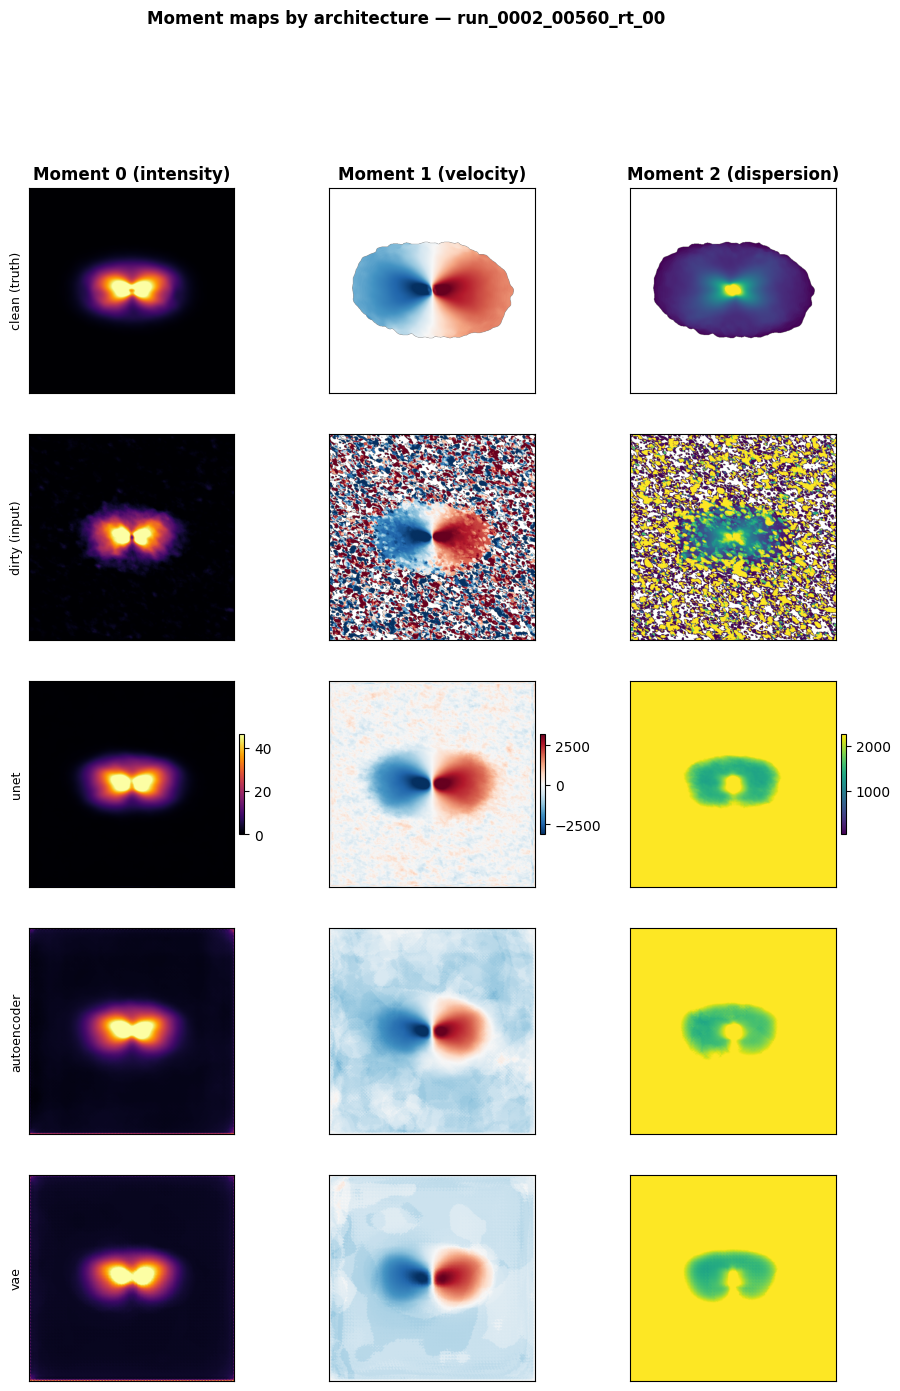

saved -> ../results/architecture_moment_maps.png


In [10]:
e = cache[MAP_CUBE]
rows_to_show = [('clean (truth)', e['clean']), ('dirty (input)', e['dirty'])] + \
               [(a, arch_maps[a]) for a in ARCHS if a in arch_maps]

cmaps = {'M0': 'inferno', 'M1': 'RdBu_r', 'M2': 'viridis'}
scales = {}
for j, m in enumerate(moments):
    ref = np.asarray(e['clean'][j], float); f_ = ref[np.isfinite(ref)]
    if m == 'M1':
        c = float(np.median(f_)); half = float(np.percentile(np.abs(f_ - c), 98))
        scales[m] = (c - half, c + half)
    else:
        scales[m] = (float(np.percentile(f_, 1)), float(np.percentile(f_, 99)))

fig, axes = plt.subplots(len(rows_to_show), 3, figsize=(11, 3.1*len(rows_to_show)))
for i, (label, maps) in enumerate(rows_to_show):
    for j, m in enumerate(moments):
        ax = axes[i, j]
        im = ax.imshow(maps[j], origin='lower', cmap=cmaps[m],
                       vmin=scales[m][0], vmax=scales[m][1])
        ax.set_xticks([]); ax.set_yticks([])
        if i == 0:
            ax.set_title({'M0':'Moment 0 (intensity)','M1':'Moment 1 (velocity)',
                          'M2':'Moment 2 (dispersion)'}[m], fontweight='bold')
        if j == 0: ax.set_ylabel(label, fontsize=9)
        if i == len(rows_to_show)-1:
            fig.colorbar(im, ax=axes[:, j].tolist(), fraction=0.02, pad=0.02)
fig.suptitle(f'Moment maps by architecture — {MAP_CUBE}', fontweight='bold', y=0.995)
p1 = os.path.join(OUT_DIR, 'architecture_moment_maps.png')
plt.savefig(p1, dpi=140, bbox_inches='tight'); plt.show()
print('saved ->', p1)

## 8. Final table — architectures on one protocol

In [11]:
print('=' * 100)
print('{:<16}{:>10}{:>12}{:>18}{:>18}{:>18}'.format(
    'architecture', 'params', 'PSNR', 'M0 (%)', 'M1 (%)', 'M2 (%)'))
print('-' * 100)
for arch in ARCHS:
    if arch not in arch_summaries: continue
    s = arch_summaries[arch]; b = best_cfg[arch]
    cfgk = dict(base_channels=int(b.base_channels))
    if arch == 'vae': cfgk['latent_dim'] = int(b.latent_dim)
    if isinstance(b.get('channel_multipliers'), str) and b['channel_multipliers'] == b['channel_multipliers']:
        cfgk['channel_multipliers'] = tuple(int(x) for x in str(b['channel_multipliers']).split('x'))
    n = param_count(arch, **cfgk)
    print('{:<16}{:>10,}{:>12.3f}{:>11.1f}+/-{:<5.1f}{:>11.1f}+/-{:<5.1f}{:>11.1f}+/-{:<5.1f}'.format(
        arch, n, retrained[arch]['psnr'],
        s['M0']['mean'], s['M0']['std'], s['M1']['mean'], s['M1']['std'],
        s['M2']['mean'], s['M2']['std']))
print('-' * 100)
print('{:<16}{:>10}{:>12.3f}{:>11.1f}+/-{:<5.1f}{:>11.1f}+/-{:<5.1f}{:>11.1f}+/-{:<5.1f}'.format(
    'U-Net V12', '3,400,000', V12['psnr'],
    V12['M0'][0], V12['M0'][1], V12['M1'][0], V12['M1'][1], V12['M2'][0], V12['M2'][1]))
print('=' * 100)
_reused = [a for a in arch_summaries if retrained[a]['epochs_run'] != retrained[a]['epochs_run']]
if _reused:
    print('\n(' + ', '.join(_reused) + ' restored from a previous session: PSNR is the one '
          'recorded then, epoch count not carried over)')
print('\nFor the classical filters on this same protocol, see 07-classical-baselines.ipynb;')
print('for the conditional DDPM, see 06-ddpm-line-emission.ipynb.')

if len(arch_summaries) > 1:
    best_arch = max(arch_summaries, key=lambda a: arch_summaries[a]['M0']['mean'])
    print(f'\nbest M0: {best_arch} at {arch_summaries[best_arch]["M0"]["mean"]:+.1f}%')
    others = [a for a in arch_summaries if a != best_arch]
    for o in others:
        gap = arch_summaries[best_arch]['M0']['mean'] - arch_summaries[o]['M0']['mean']
        pooled = float(np.sqrt(arch_summaries[best_arch]['M0']['std']**2 +
                               arch_summaries[o]['M0']['std']**2)) or 1e-12
        verdict = 'REAL' if abs(gap) > 2*pooled else ('suggestive' if abs(gap) > pooled
                                                      else 'within cube-to-cube spread')
        print(f'  vs {o:<12} {gap:+6.1f} pp (pooled spread {pooled:.1f}) -> {verdict}')
    print('\nEach architecture is a SINGLE retrained run; only the cube-to-cube spread is')
    print('shown, not seed spread. V16 showed a single run can be 6.8 dB off. Treat an')
    print('architecture gap inside the spread as unproven and repeat it with 08-style seeds.')

architecture        params        PSNR            M0 (%)            M1 (%)            M2 (%)
----------------------------------------------------------------------------------------------------
unet             3,477,665      37.414      -33.2+/-71.8        68.7+/-22.5      -152.8+/-81.6 
autoencoder      1,734,305      33.155     -152.0+/-267.8       58.2+/-30.2       -46.1+/-44.1 
vae                467,793      29.760     -220.4+/-295.1       45.7+/-29.1       -75.9+/-70.0 
----------------------------------------------------------------------------------------------------
U-Net V12        3,400,000      32.950       69.8+/-15.2        17.5+/-7.8         20.1+/-14.3 

(unet, autoencoder, vae restored from a previous session: PSNR is the one recorded then, epoch count not carried over)

For the classical filters on this same protocol, see 07-classical-baselines.ipynb;
for the conditional DDPM, see 06-ddpm-line-emission.ipynb.

best M0: unet at -33.2%
  vs autoencoder  +118.8 pp (pool

## 9. Persist

In [12]:
arch_csv = os.path.join(OUT_DIR, 'architecture_moment_summary.csv')
with open(arch_csv, 'w', newline='') as f:
    w = csv.writer(f); w.writerow(['arch','cube','imp_M0','imp_M1','imp_M2'])
    for arch, rows in arch_rows.items():
        for r in rows: w.writerow([arch, r['cube'], r['imp_M0'], r['imp_M1'], r['imp_M2']])
        s = arch_summaries[arch]
        w.writerow([arch,'MEAN'] + [round(s[m]['mean'],2) for m in moments])
        w.writerow([arch,'STD']  + [round(s[m]['std'],2)  for m in moments])
print('saved ->', arch_csv)

import shutil
if ON_KAGGLE:
    for p in [x for x in [SWEEP_CSV, ARCH_CSV, MAPS_NPZ, arch_csv, p1]
              if os.path.dirname(os.path.abspath(x)) != '/kaggle/working'] + \
             [os.path.join(CKPT_DIR, f'arch_{a}_best.pth') for a in arch_summaries]:
        if os.path.exists(p):
            shutil.copy2(p, '/kaggle/working/' + os.path.basename(p))
            print('persisted ->', os.path.basename(p))
    print('\ndownload the CSVs from the kernel Output tab and commit them to results/')
else:
    print('not on Kaggle — nothing to persist')

saved -> ../results/architecture_moment_summary.csv
persisted -> architecture_moment_summary.csv
persisted -> architecture_moment_maps.png
persisted -> arch_unet_best.pth
persisted -> arch_autoencoder_best.pth
persisted -> arch_vae_best.pth

download the CSVs from the kernel Output tab and commit them to results/


## Collect this notebook's outputs

Every artifact this notebook produced, copied into a **versioned run folder** together with
a manifest recording the commit, the UTC time and a checksum per file:

    <outputs>/09-architecture-comparison/<UTC timestamp>_<git sha>/

Nothing overwrites anything, so two runs can be compared directly. Results used to land in
one flat `results/` directory with no record of which notebook or which revision wrote them
-- a moment CSV from before the M2 noise-clip fix was indistinguishable from one after it.

On Kaggle this writes to `/kaggle/working/outputs/`, at the top level, so the bundle is
unambiguously part of the notebook Output rather than buried in the git clone. Download that
folder and commit it under `DENOISING_DIFFUSION/results/`.


In [ ]:
from src.evaluation.collect_outputs import collect_outputs

_run_dir = collect_outputs(
    '09-architecture-comparison',
    [
        'architecture_sweep.csv',
        'architecture_moment_rows.csv',
        'architecture_moment_summary.csv',
        'architecture_moment_maps.png',
        'architecture_moment_maps.npz',
        'arch_*_best.pth',
    ],
)
